# Memcached RDMA/Hermit cgroup result summary

This notebook reads the merged CSV files and displays the generated figures. It does not embed benchmark rows directly.


## CSV inputs

The plots below are generated from these CSV files:

- `results/memcached_151557_after_core_merged.csv`
- `results/memcached_222219_jupyter_summary.csv`
- `results/memcached_222219_vs_151557.csv`


In [10]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if (ROOT / "tools/rdma/results").exists():
    RESULT_DIR = ROOT / "tools/rdma/results"
elif (ROOT / "results").exists():
    RESULT_DIR = ROOT / "results"
else:
    RESULT_DIR = Path("/home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results")

csv_files = {
    "151557 merged": RESULT_DIR / "memcached_151557_after_core_merged.csv",
    "222219 stable median": RESULT_DIR / "memcached_222219_jupyter_summary.csv",
    "222219 vs 151557": RESULT_DIR / "memcached_222219_vs_151557.csv",
}

data = {name: pd.read_csv(path) for name, path in csv_files.items()}
for name, frame in data.items():
    print(f"{name}: {len(frame)} rows -> {csv_files[name]}")


151557 merged: 72 rows -> /home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results/memcached_151557_after_core_merged.csv
222219 stable median: 24 rows -> /home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results/memcached_222219_jupyter_summary.csv
222219 vs 151557: 24 rows -> /home/fermata/Development/repos/fastswap/hermit-6/tools/rdma/results/memcached_222219_vs_151557.csv


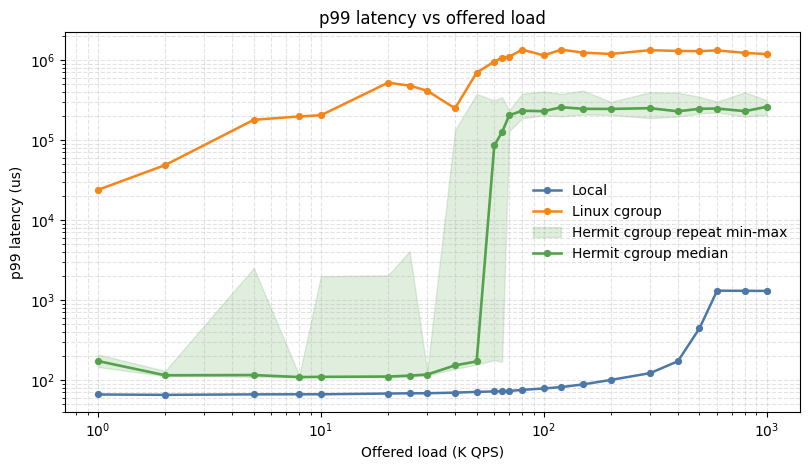

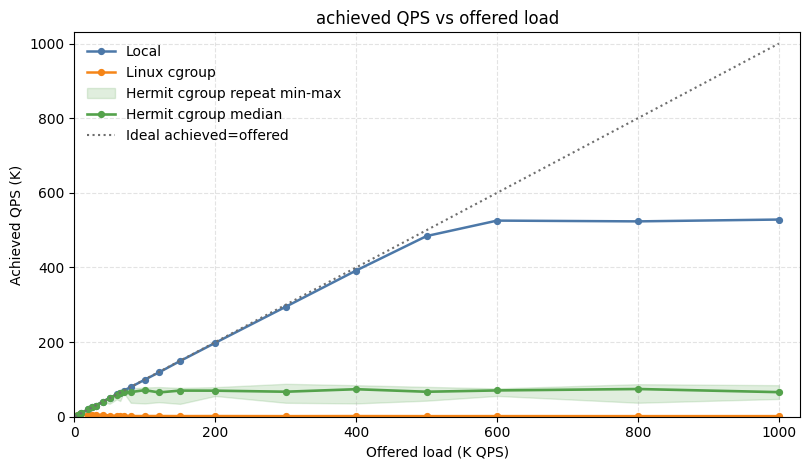

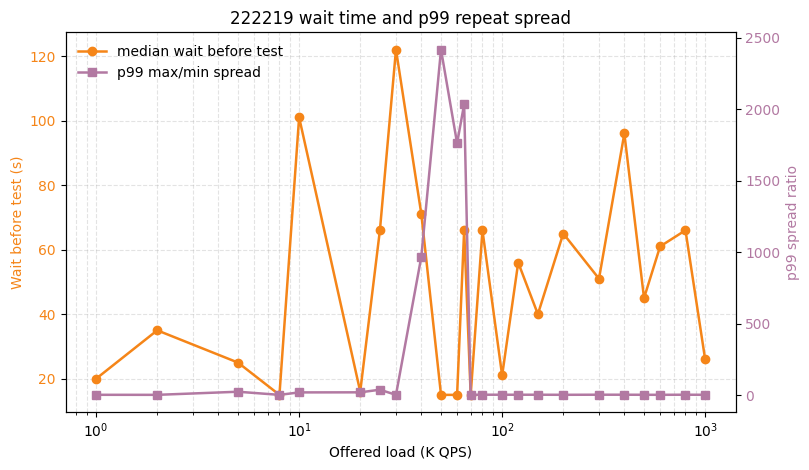

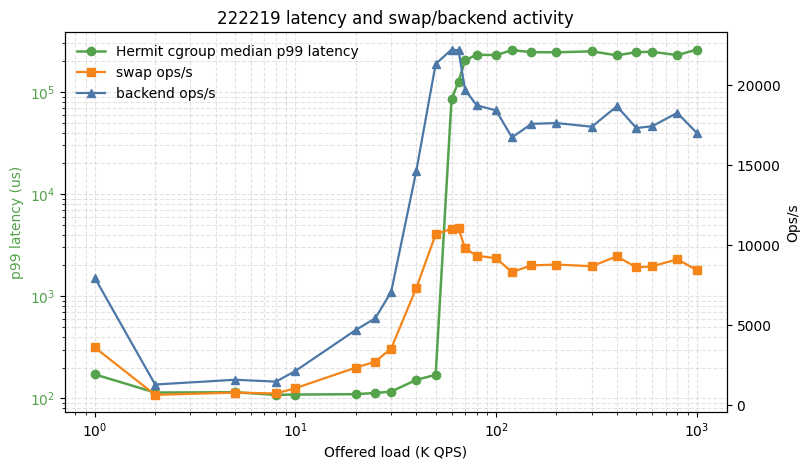

In [11]:
import matplotlib.pyplot as plt
import pandas as pd


def numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    text_cols = {
        "run_id",
        "mode",
        "system",
        "memcached_cores",
        "mutilate_cores",
        "repeat",
        "wait_status",
        "log_file",
        "kernel_tag",
        "uname",
    }
    for col in df.columns:
        if col not in text_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


merged151 = numeric_columns(data["151557 merged"].copy())
stable222 = numeric_columns(data["222219 stable median"].copy()).sort_values("offered_qps")
compare = numeric_columns(data["222219 vs 151557"].copy())

colors = {
    "Local": "#4c78a8",
    "Linux cgroup": "#f58518",
    "Hermit cgroup": "#54a24b",
    "Ideal": "#6e6e6e",
}

local151 = merged151[merged151["system"] == "Local"].sort_values("offered_qps")
linux151 = merged151[merged151["system"] == "Linux cgroup"].sort_values("offered_qps")
x222 = stable222["offered_qps"] / 1000


def finish(ax, title, xlabel="Offered load (K QPS)"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# Combined p99 latency: Local/Linux from 151557, Hermit cgroup uses 222219 stable median by default.
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for system, group in (("Local", local151), ("Linux cgroup", linux151)):
    ax.plot(
        group["offered_qps"] / 1000,
        group["read_p99_us"],
        marker="o",
        linewidth=1.8,
        markersize=4.2,
        label=system,
        color=colors[system],
    )
ax.fill_between(
    x222,
    stable222["read_p99_us_min"],
    stable222["read_p99_us_max"],
    color=colors["Hermit cgroup"],
    alpha=0.18,
    label="Hermit cgroup repeat min-max",
)
ax.plot(
    x222,
    stable222["read_p99_us"],
    marker="o",
    linewidth=1.9,
    markersize=4.2,
    color=colors["Hermit cgroup"],
    label="Hermit cgroup median",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("p99 latency (us)")
finish(ax, "p99 latency vs offered load")

# Achieved QPS: Local/Linux from 151557, Hermit cgroup uses 222219 stable median by default.
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for system, group in (("Local", local151), ("Linux cgroup", linux151)):
    ax.plot(
        group["offered_qps"] / 1000,
        group["achieved_qps"] / 1000,
        marker="o",
        linewidth=1.8,
        markersize=4.2,
        label=system,
        color=colors[system],
    )
ax.fill_between(
    x222,
    stable222["achieved_qps_min"] / 1000,
    stable222["achieved_qps_max"] / 1000,
    color=colors["Hermit cgroup"],
    alpha=0.18,
    label="Hermit cgroup repeat min-max",
)
ax.plot(
    x222,
    stable222["achieved_qps"] / 1000,
    marker="o",
    linewidth=1.9,
    markersize=4.2,
    color=colors["Hermit cgroup"],
    label="Hermit cgroup median",
)
ideal_x = sorted(set((merged151["offered_qps"] / 1000).dropna()).union(set(x222.dropna())))
ax.plot(
    ideal_x,
    ideal_x,
    linestyle=":",
    linewidth=1.5,
    color=colors["Ideal"],
    label="Ideal achieved=offered",
)
ax.set_xlim(0, max(ideal_x) * 1.03)
ax.set_ylim(0, max(ideal_x) * 1.03)
ax.set_ylabel("Achieved QPS (K)")
finish(ax, "achieved QPS vs offered load")

fig, ax1 = plt.subplots(figsize=(8.2, 4.8))
ax1.plot(
    x222,
    stable222["wait_before_sec"],
    marker="o",
    linewidth=1.8,
    color="#f58518",
    label="median wait before test",
)
ax1.set_xscale("log")
ax1.set_xlabel("Offered load (K QPS)")
ax1.set_ylabel("Wait before test (s)", color="#f58518")
ax1.tick_params(axis="y", labelcolor="#f58518")
ax1.grid(True, which="both", linestyle="--", alpha=0.35)
ax2 = ax1.twinx()
ax2.plot(
    x222,
    stable222["p99_spread_ratio"],
    marker="s",
    linewidth=1.8,
    color="#b279a2",
    label="p99 max/min spread",
)
ax2.set_ylabel("p99 spread ratio", color="#b279a2")
ax2.tick_params(axis="y", labelcolor="#b279a2")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], frameon=False, loc="upper left")
ax1.set_title("222219 wait time and p99 repeat spread")
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(8.2, 4.8))
ax1.plot(
    x222,
    stable222["read_p99_us"],
    marker="o",
    linewidth=1.8,
    color=colors["Hermit cgroup"],
    label="Hermit cgroup median p99 latency",
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Offered load (K QPS)")
ax1.set_ylabel("p99 latency (us)", color=colors["Hermit cgroup"])
ax1.tick_params(axis="y", labelcolor=colors["Hermit cgroup"])
ax1.grid(True, which="both", linestyle="--", alpha=0.35)
ax2 = ax1.twinx()
ax2.plot(
    x222,
    stable222["swap_ops_per_s"],
    marker="s",
    linewidth=1.6,
    color="#f58518",
    label="swap ops/s",
)
ax2.plot(
    x222,
    stable222["backend_ops_per_s"],
    marker="^",
    linewidth=1.6,
    color="#4c78a8",
    label="backend ops/s",
)
ax2.set_ylabel("Ops/s")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], frameon=False, loc="upper left")
ax1.set_title("222219 latency and swap/backend activity")
plt.tight_layout()
plt.show()
